In [ ]:
# https://xlerobot.readthedocs.io/en/latest/software/index.html
# Exactly follow the above docs and move files 
# Configure the motors for SO101 arms and other motors if you haven’t done so. following my 0- notebook only for assigning motors ID

In [ ]:
# Clone the github and check (Uninstall existing lerobot pip versions)
! git clone https://github.com/huggingface/lerobot.git
! cd lerobot
! pip install -e .
! python -c "import lerobot; print(lerobot.__file__)"

- If you dont understand any lerobot-command then type in cmd 
```bash
lerobot-command --help
```

```java
(pytorch-miniconda) C:\Users\SriRam.A\Documents\sr_proj\RoboticArm\lerobot>python -c "import lerobot; print(lerobot.__file__)"
C:\Users\SriRam.A\Documents\sr_proj\RoboticArm\lerobot\src\lerobot\__init__.py```

In [ ]:
# https://huggingface.co/docs/lerobot/installation
! pip install -e ".[feetech]"

## Motors ID and Ports

In [10]:
# get USB port id 
! mode


Status for device COM3:
-----------------------
    Baud:            19200
    Parity:          None
    Data Bits:       8
    Stop Bits:       1
    Timeout:         OFF
    XON/XOFF:        OFF
    CTS handshaking: OFF
    DSR handshaking: OFF
    DSR sensitivity: OFF
    DTR circuit:     ON
    RTS circuit:     ON


Status for device CON:
----------------------
    Lines:          9001
    Columns:        120
    Keyboard rate:  31
    Keyboard delay: 1
    Code page:      437



In [14]:
# Check once again if all motors are available
from scservo_sdk import *
port = PortHandler("COM3")
packet = PacketHandler(1)   # protocol 1
if not port.openPort():
    print("❌ Failed to open port")
port.setBaudRate(1000000)
print("✅ Port opened")
found = []
for i in range(0, 20):
    model, comm_result, error = packet.ping(port, i)
    if comm_result == COMM_SUCCESS:
        print(f"FOUND servo ID {i}, model {model}")
        found.append(i)
print("FINAL FOUND:", found)

✅ Port opened


FOUND servo ID 1, model 2307
FOUND servo ID 2, model 2307
FOUND servo ID 3, model 2307
FOUND servo ID 4, model 2307
FOUND servo ID 5, model 2307
FOUND servo ID 6, model 2307
FINAL FOUND: [1, 2, 3, 4, 5, 6]


In [ ]:
! lerobot-find-port

```java
Finding all available ports for the MotorsBus.
Ports before disconnecting: ['COM3']
Remove the USB cable from your MotorsBus and press Enter when done.

The port of this MotorsBus is 'COM3'
Reconnect the USB cable.
```

### Error
- After some time couldnt get motor ID 1 and 6 
- Same error in phosphobot
Follow : https://huggingface.co/docs/lerobot/en/so100
```java
2026-01-02 12:27:20.875 | WARNING  | phosphobot.hardware.so100:read_motor_temperature:400 - Error reading motor temperature for servo 1: Read failed due to communication error on port COM3 for group_key Present_Temperature_shoulder_pan: [TxRxResult] There is no status packet!   
2026-01-02 12:27:21.403 | WARNING  | phosphobot.hardware.so100:read_motor_temperature:400 - Error reading motor temperature for servo 6: Read failed due to communication error on port COM3 for group_key Present_Temperature_gripper: [TxRxResult] Incorrect status packet!
```

In [ ]:
# https://huggingface.co/docs/lerobot/en/so101#setup-motors-video
! lerobot-setup-motors --robot.type=so100_follower --robot.port=COM3

![image.png](screenshots/motor_id.png)

# Calibrate

In [ ]:
#  Guidance video : https://huggingface.co/docs/lerobot/en/so101#calibration-video
# I did Ctrl+P and then typed so100 , I got a mdx file and started reading : C:\Users\SriRam.A\Documents\sr_proj\RoboticArm\lerobot\docs\source\so100.mdx
! lerobot-calibrate --robot.type=so100_follower --robot.port=COM3 --robot.id=so100


```java
INFO 2026-01-02 10:12:51 calibrate.py:76 {'robot': {'calibration_dir': None,
           'cameras': {},
           'disable_torque_on_disconnect': True,
           'id': 'so100',
           'max_relative_target': None,
           'port': 'COM3',
           'use_degrees': False},
 'teleop': None}
INFO 2026-01-02 10:12:51 follower.py:104 so100 SO100Follower connected.
INFO 2026-01-02 10:12:51 follower.py:121 
Running calibration of so100 SO100Follower
Move so100 SO100Follower to the middle of its range of motion and press ENTER....
Move all joints except 'wrist_roll' sequentially through their entire ranges of motion.
Recording positions. Press ENTER to stop...

-------------------------------------------
NAME            |    MIN |    POS |    MAX
shoulder_pan    |   2039 |   2045 |   2047
shoulder_lift   |   2002 |   2010 |   2149
elbow_flex      |   1774 |   1890 |   2047
wrist_flex      |   2047 |   2280 |   2797
gripper         |   2047 |   2047 |   2048
Calibration saved to C:\Users\SriRam.A\.cache\huggingface\lerobot\calibration\robots\so100_follower\so100.json
INFO 2026-01-02 10:13:51 follower.py:232 so100 SO100Follower disconnected.
```

### FeetechMotorsBus motor check failed on port 'COM3'
```bash
RuntimeError: FeetechMotorsBus motor check failed on port 'COM3':
Missing motor IDs:
  - 1 (expected model: 777)
  - 2 (expected model: 777)
  - 3 (expected model: 777)
  - 4 (expected model: 777)
  - 5 (expected model: 777)
  - 6 (expected model: 777)
Full expected motor list (id: model_number):
{1: 777, 2: 777, 3: 777, 4: 777, 5: 777, 6: 777}
Full found motor list (id: model_number):
{}
```
### Solution:
Servo bus has NO POWER (most common)
The USB cable does NOT power the servos.
Install feetech as mentioned above

- Succesfully calibrated
![claibrated.png](screenshots/calibrated.png)

# Teleoperate

### Erorr : SerialException: could not open port 'COM3': PermissionError(13, 'Access is denied.', None, 5)
- remove and reconnect USB to same port again

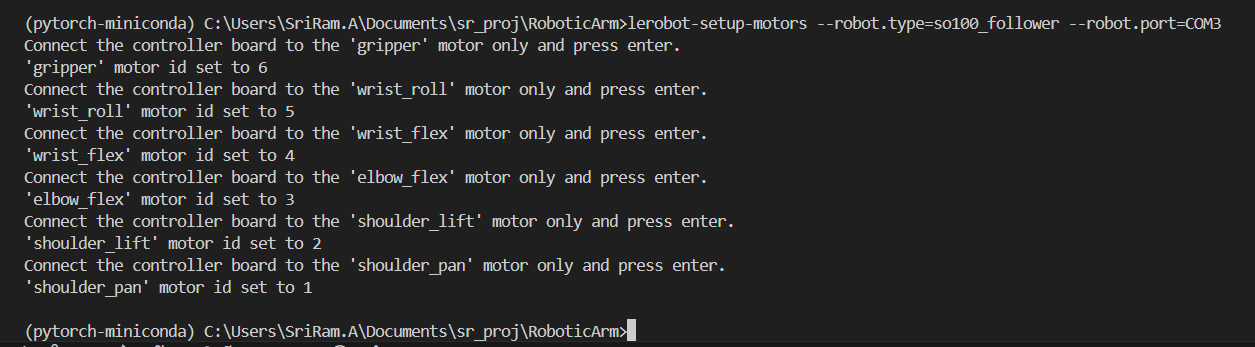

In [ ]:
! pip install pygame
# Keyboard
! lerobot-teleoperate --robot.type=so100_follower --robot.port=COM3 --robot.id=so100 --teleop.type=keyboard
# Controller
! lerobot-teleoperate --robot.type=so100_follower --robot.port=COM3 --robot.id=so100 --teleop.type=gamepad

! lerobot-teleoperate  --robot.type=so100_follower  --robot.port=COM3  --robot.id=so100  --robot.disable_torque_on_disconnect=false  --teleop.type=gamepad  --teleop.id=xbox_controller

! lerobot-teleoperate  --robot.type=so100_follower  --robot.port=COM3  --robot.id=so100  --robot.handshake=false  --teleop.type=gamepad  --teleop.id=xbox_controller



In [ ]:
# --robot.cameras="{ front: {type: opencv, index_or_path: 0, width: 1920, height: 1080, fps: 30}}"

In [ ]:
# import cv2

# for i in range(10):
#     cap = cv2.VideoCapture(i)
#     if cap.isOpened():
#         ret, frame = cap.read()
#         print(f"Camera index {i}: {'OK' if ret else 'No frame'}")
#         print(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
#         print(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
#         print(cap.get(cv2.CAP_PROP_FPS))
#         cap.release()
